In [75]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
########################################################################

# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# true_time=data['time']
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='1e6'
# #Restricts the timesteps of the data from timesteps0 to 140
# res='1km';t_res='5min'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'


# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'


In [76]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
index_adjust=0
ocean_fraction=0.25

In [77]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [78]:
#READING BACK IN

types = ["ALL", "SHALLOW", "DEEP"]
variables = ["W", "QV", "QCQI", "TH", "TH_E", "BUOYANCY", "HMC"]

vars_list = []
SE_list = []

for t in types:
    for var in variables:
        vars_list.append(f"CL_{t}_profile_array_{var.lower()}")
        vars_list.append(f"nonCL_{t}_profile_array_{var.lower()}")
# for t in types:
#     for var in variables:
#         SE_list.append(f"CL_{t}_SE_{var.lower()}")
#         SE_list.append(f"nonCL_{t}_SE_{var.lower()}")

# Define directory and output file path
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
# input_file=dir2+f"CL_nonCL_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
input_file=dir2+f"CL_nonCL_tracked_profiles_{res}_{t_res}_{Np_str}.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(input_file, 'r') as f:
    for var in vars_list: #+ SE_list:
        globals()[var] = f[f'{var}'][:]

In [41]:
##################################
#PLOTTING

In [42]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



In [43]:
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data\n"
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [44]:
def averaged_profile_SE(profile): 

    ######################################## (MOVED TO SE_averaged_profilesssFUNCTION)
    mask=np.where(profile[:,1]!=0)
    
    #DIVIDE BY N = n-1
    with np.errstate(divide='ignore', invalid='ignore'):
        profile[mask, 0] /= (profile[mask, 1]-1) 
    #TAKE THE SQUARE ROOT
    profile[mask,0]=np.sqrt(profile[mask,0]) 
    #DIVIDE BY SQUARE ROOT OF n ==> STANDARD ERROR
    profile[mask, 0] /= np.sqrt(profile[mask, 1]) 

    #SETTING TO NAN WHERE UNDEFINED
    where_undefined=np.where(profile[:,1]==1)
    profile[where_undefined,0]=np.nan #=0
    ########################################
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels



In [45]:
# List of variables with their corresponding labels and x-axis titles
var_units = [
    ("w", 'w (m/s)'),
    ("qv", r"$q_v$ (g/kg)"),
    ("qcqi", r"$q_c+q_i$ (g/kg)"),
    ("th", r"$\theta$ (K)"),
    ("th_e", r"$\theta_e$ (K)"),
    ("buoyancy", r"Buoyancy $(m/s^2)$"),
    ("hmc", "HMC (g/kg/s)"),
]

In [46]:
SE_ARRAYS=False
# SE_ARRAYS=True

if SE_ARRAYS==False:
    #IF NOT USING SE ARRAYS
    for type2 in ['ALL','SHALLOW','DEEP']:
        for type1 in ['CL','nonCL','SBZ','nonSBZ','ColdPool']:
            for var in [var_unit[0] for var_unit in var_units]: 
                globals()[f"{type1}_{type2}_SE_{var}"]=np.zeros_like(CL_ALL_profile_array_w[:,0:3])

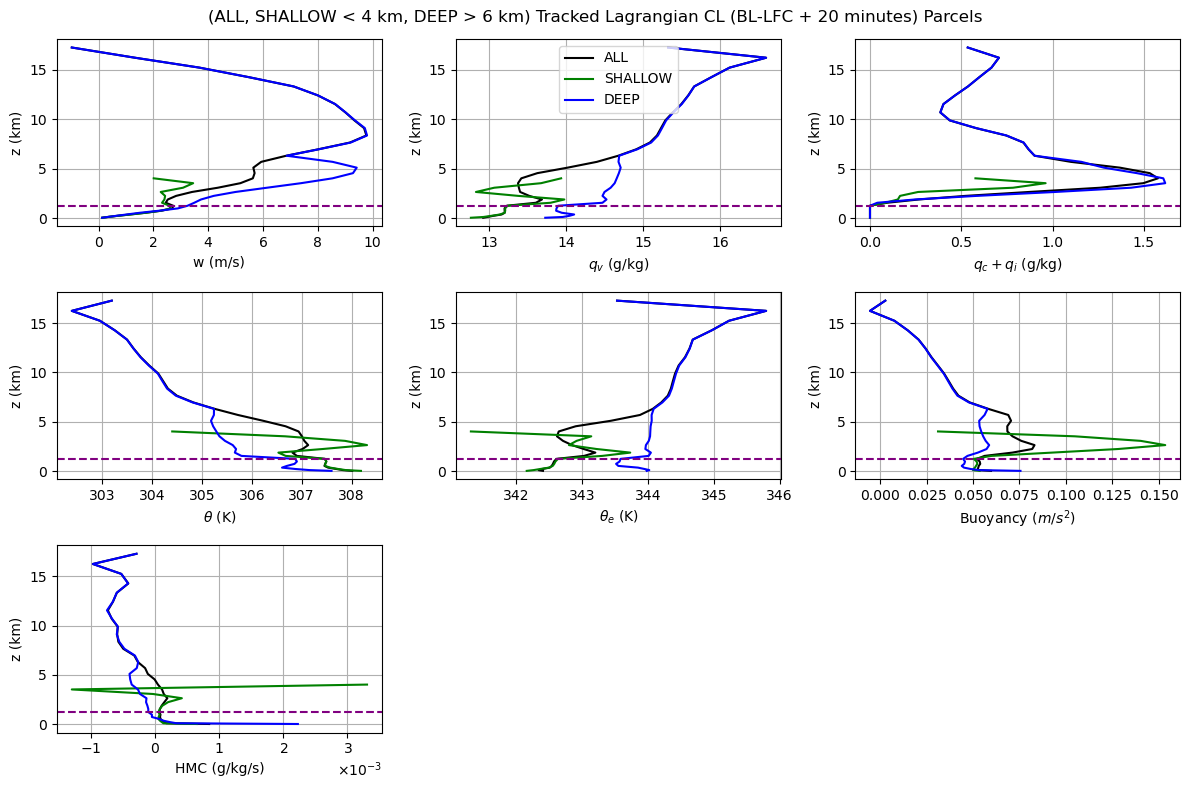

In [47]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"CL_ALL_profile_array_{var}"].copy(),
        globals()[f"CL_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"CL_DEEP_profile_array_{var}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"CL_ALL_SE_{var}"].copy(),
        globals()[f"CL_SHALLOW_SE_{var}"].copy(),
        globals()[f"CL_DEEP_SE_{var}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        # ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


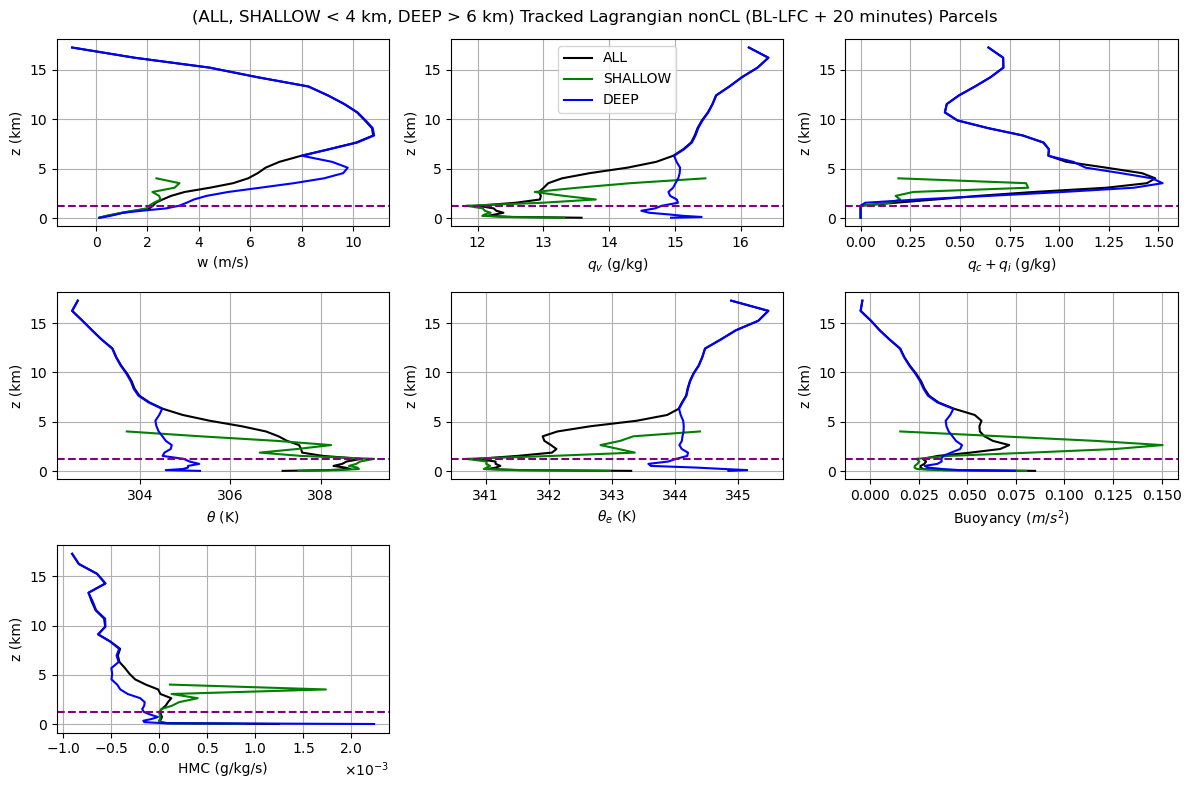

In [59]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"nonCL_ALL_profile_array_{var}"].copy(),
        globals()[f"nonCL_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"nonCL_DEEP_profile_array_{var}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"nonCL_ALL_SE_{var}"].copy(),
        globals()[f"nonCL_SHALLOW_SE_{var}"].copy(),
        globals()[f"nonCL_DEEP_SE_{var}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        # ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian nonCL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [51]:
#DIFFERENCES

def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var_names = [var[0] for var in var_units]
categories = ["ALL", "SHALLOW", "DEEP"]

for var in var_names:
    for cat in categories:
        # Construct the variable names dynamically
        CL_profile = globals()[f"CL_{cat}_profile_array_{var}"]
        nonCL_profile = globals()[f"nonCL_{cat}_profile_array_{var}"]
        
        # Calculate the difference and assign it to the global variable
        globals()[f"{cat}_diff_{var}"] = average_difference(CL_profile, nonCL_profile)
print('done')

done


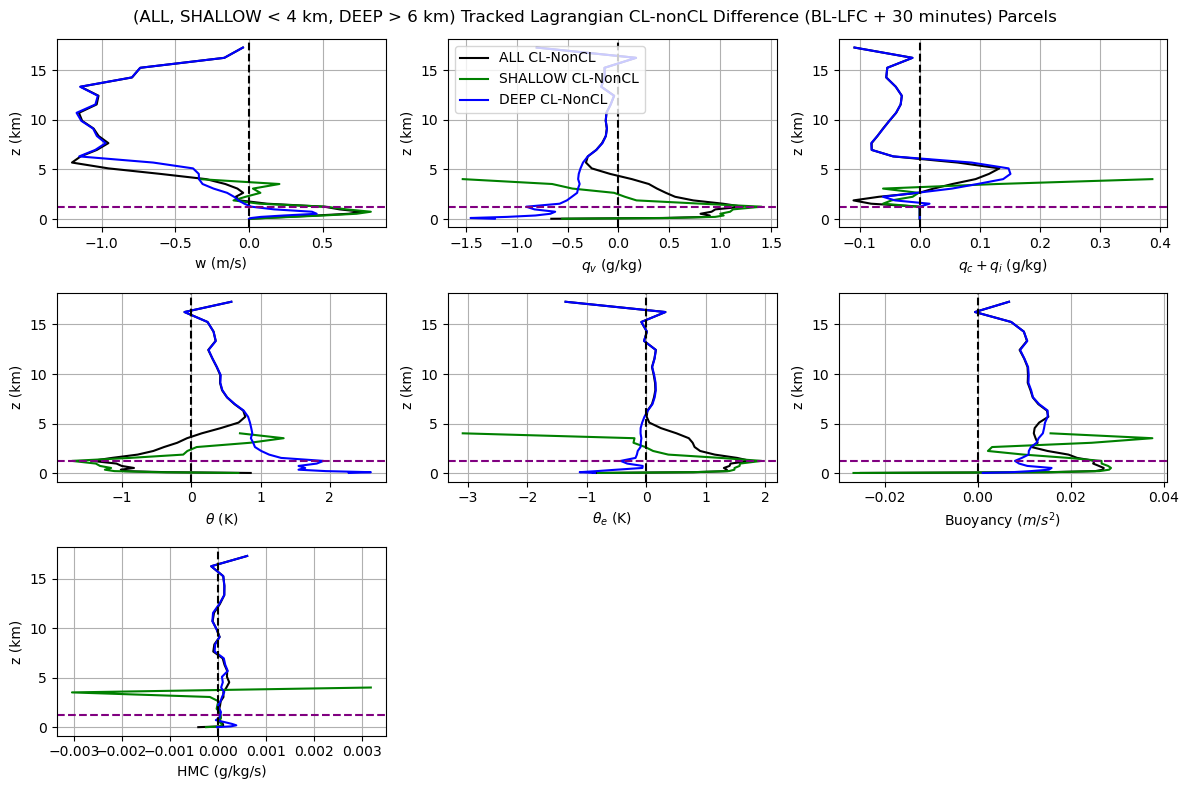

In [60]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Construct profiles dynamically using globals()
profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL-nonCL Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [53]:
#SBZ vs nonSBZ
################################################################################

In [54]:
##################################
#PLOTTING

In [61]:
#READING BACK IN

types = ["ALL", "SHALLOW", "DEEP"]
variables = ["W", "QV", "QCQI", "TH", "TH_E", "BUOYANCY", "HMC"]

vars_list = []
SE_list = []
for t in types:
    for var in variables:
        vars_list.append(f"SBZ_{t}_profile_array_{var.lower()}")
        vars_list.append(f"nonSBZ_{t}_profile_array_{var.lower()}")
for t in types:
    for var in variables:
        SE_list.append(f"SBZ_{t}_SE_{var.lower()}")
        SE_list.append(f"nonSBZ_{t}_SE_{var.lower()}")

# Define directory and output file path
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
# output_file=dir2+f"SBZ_nonSBZ_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
output_file=dir2+f"SBZ_nonSBZ_tracked_profiles_{res}_{t_res}_{Np_str}.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(output_file, 'r') as f:
    for var in vars_list:# + SE_list:
        globals()[var] = f[f'{var}'][:]

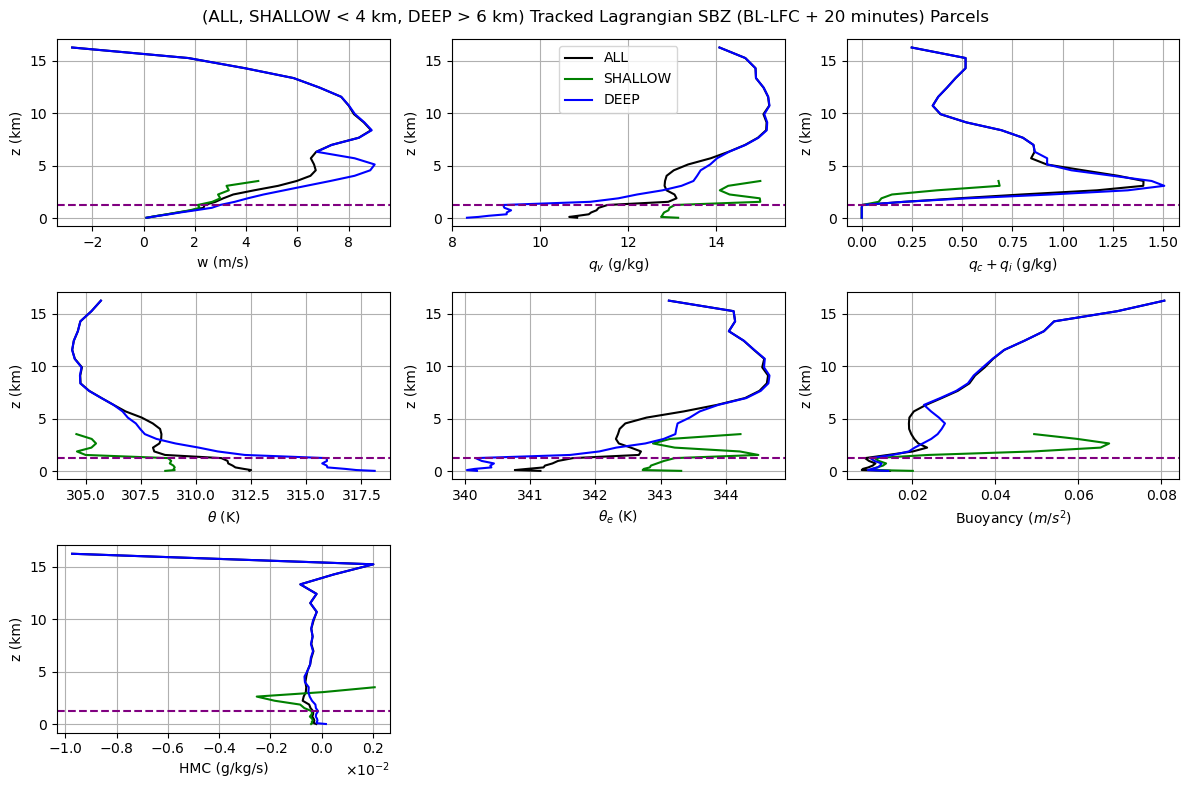

In [62]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"SBZ_ALL_profile_array_{var}"].copy(),
        globals()[f"SBZ_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"SBZ_DEEP_profile_array_{var}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"SBZ_ALL_SE_{var}"].copy(),
        globals()[f"SBZ_SHALLOW_SE_{var}"].copy(),
        globals()[f"SBZ_DEEP_SE_{var}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        # ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


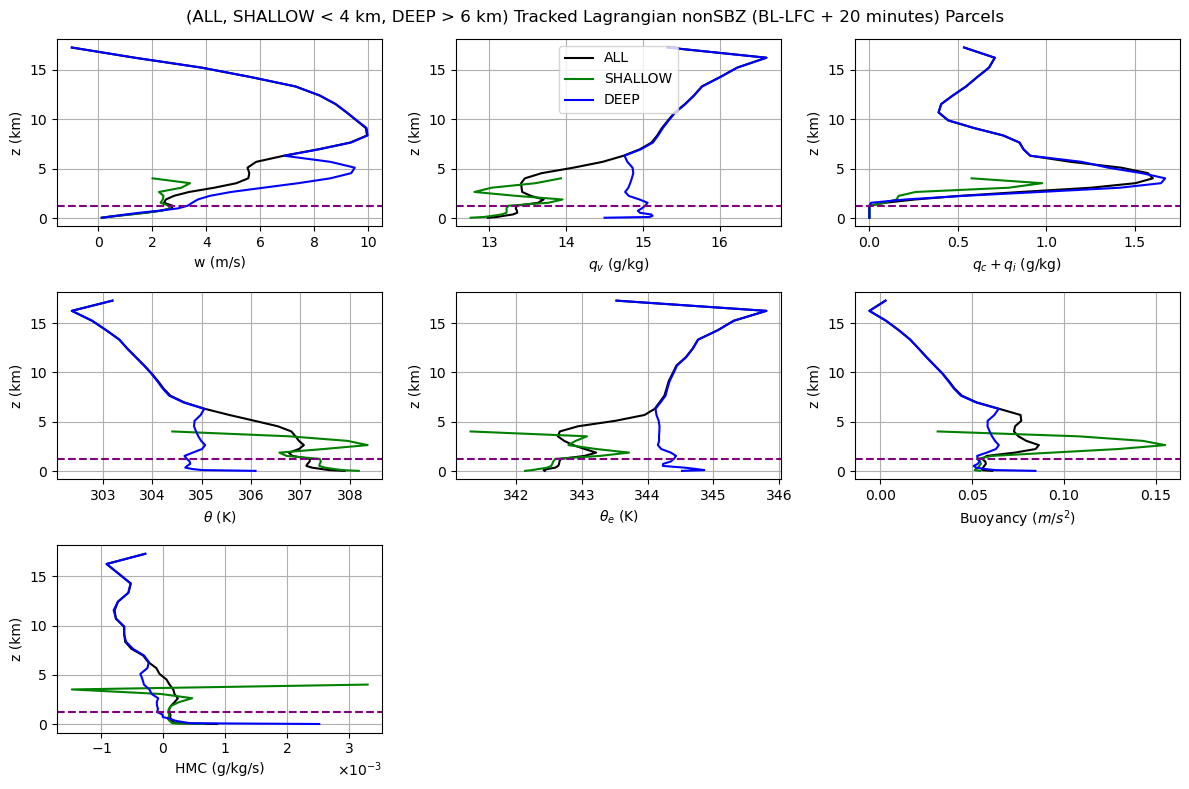

In [63]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"nonSBZ_ALL_profile_array_{var}"].copy(),
        globals()[f"nonSBZ_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"nonSBZ_DEEP_profile_array_{var}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"nonSBZ_ALL_SE_{var}"].copy(),
        globals()[f"nonSBZ_SHALLOW_SE_{var}"].copy(),
        globals()[f"nonSBZ_DEEP_SE_{var}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        # ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [64]:
#SBZ vs nonSBZ
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
    

var_names = [var[0] for var in var_units]
categories = ["ALL", "SHALLOW", "DEEP"]

for var in var_names:
    for cat in categories:
        # Construct the variable names dynamically
        CL_profile = globals()[f"SBZ_{cat}_profile_array_{var}"]
        nonCL_profile = globals()[f"nonSBZ_{cat}_profile_array_{var}"]
        
        # Calculate the difference and assign it to the global variable
        globals()[f"{cat}_diff_{var}"] = average_difference(CL_profile, nonCL_profile)
print('done')

done


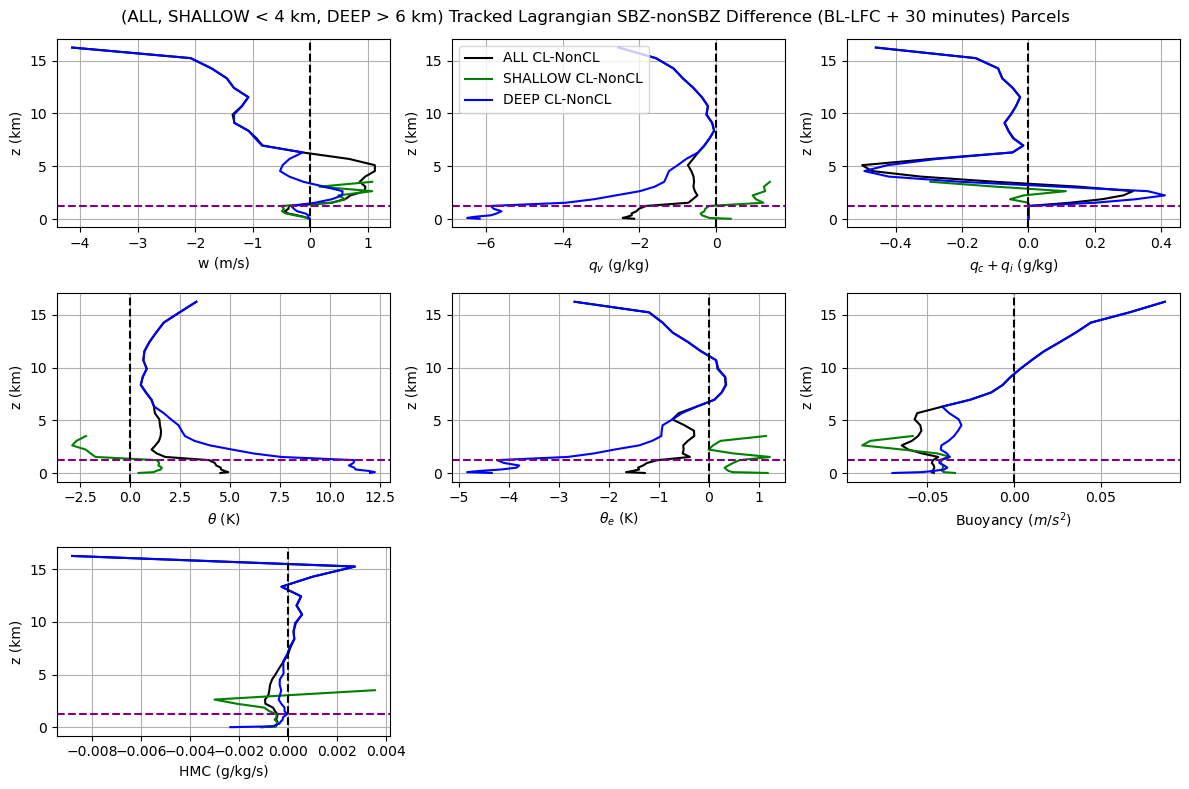

In [65]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Construct profiles dynamically using globals()
profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ-nonSBZ Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [ ]:
#ColdPool
################################################################

In [ ]:
#PLOTTING
############################################################

In [67]:
#READING BACK IN

types = ["ALL", "SHALLOW", "DEEP"]
variables = ["W", "QV", "QCQI", "TH", "TH_E", "BUOYANCY", "HMC"]

vars_list = []
SE_list = []

for t in types:
    for var in variables:
        vars_list.append(f"ColdPool_{t}_profile_array_{var.lower()}")
# for t in types:
#     for var in variables:
#         SE_list.append(f"ColdPool_{t}_SE_{var.lower()}")
        
# Define directory and output file path
dir2=dir+'Project_Algorithms/Tracked_Profiles/job_out2/'
# output_file=dir2+f"ColdPool_tracked_profiles_SE_{res}_{t_res}_{Np_str}.h5"
output_file=dir2+f"ColdPool_tracked_profiles_{res}_{t_res}_{Np_str}.h5"

# Open the HDF5 file and read the stored datasets into dynamically named variables
with h5py.File(output_file, 'r') as f:
    for var in vars_list:# + SE_list:
        globals()[var] = f[f'{var}'][:]

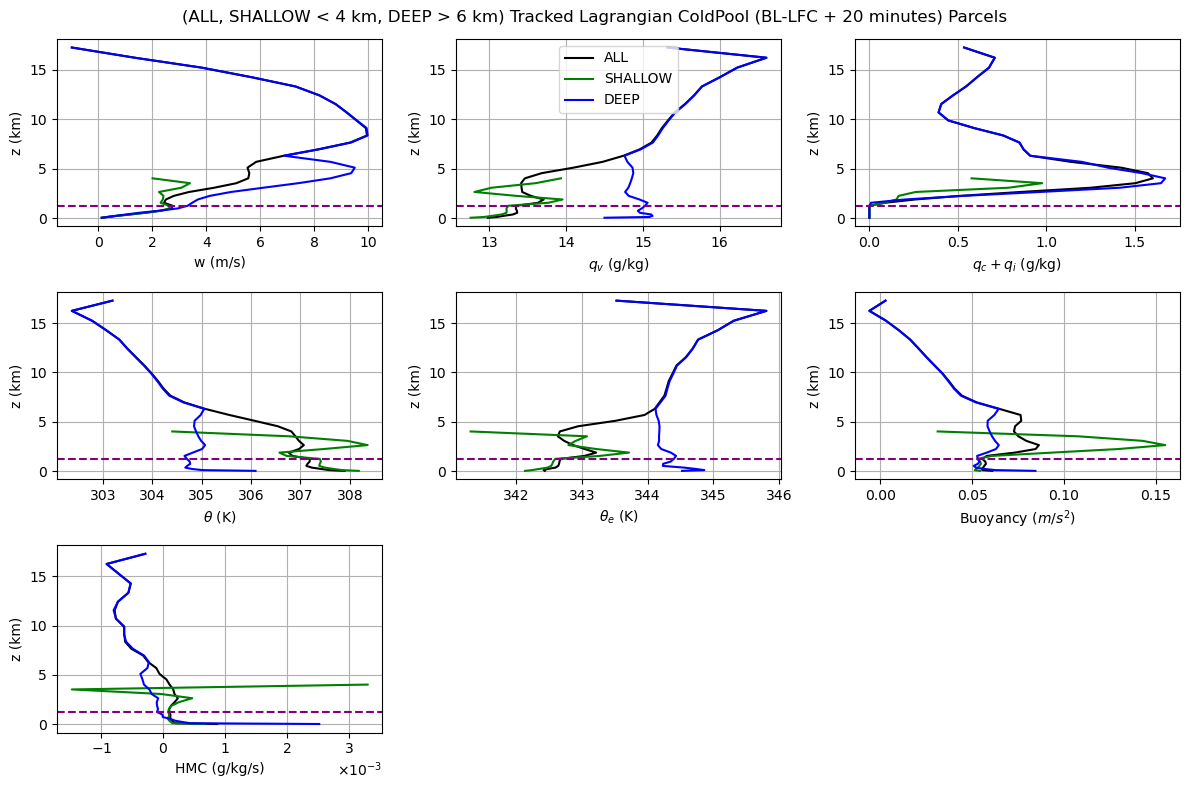

In [70]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"ColdPool_ALL_profile_array_{var}"].copy(),
        globals()[f"ColdPool_SHALLOW_profile_array_{var}"].copy(),
        globals()[f"ColdPool_DEEP_profile_array_{var}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"ColdPool_ALL_SE_{var}"].copy(),
        globals()[f"ColdPool_SHALLOW_SE_{var}"].copy(),
        globals()[f"ColdPool_DEEP_SE_{var}"].copy(),
        None  # placeholder for xlabel not used in SE
    ))

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        SE=averaged_profile_SE(SE_profile) #***
        switch=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=0
        #STANDARD ERROR SHADING
        # ax.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0]*switch, profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1) #***
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian ColdPool (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [73]:
#SBZ vs ColdPool
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
    
# Calculate average differences for each variable (w, qv, qc, th, buoyancy) for ColdPool

var_names = [var[0] for var in var_units]
categories = ["ALL", "SHALLOW", "DEEP"]

for var in var_names:
    for cat in categories:
        # Construct the variable names dynamically
        CL_profile = globals()[f"SBZ_{cat}_profile_array_{var}"]
        nonCL_profile = globals()[f"ColdPool_{cat}_profile_array_{var}"]
        
        # Calculate the difference and assign it to the global variable
        globals()[f"{cat}_diff_{var}"] = average_difference(CL_profile, nonCL_profile)
print('done')

done


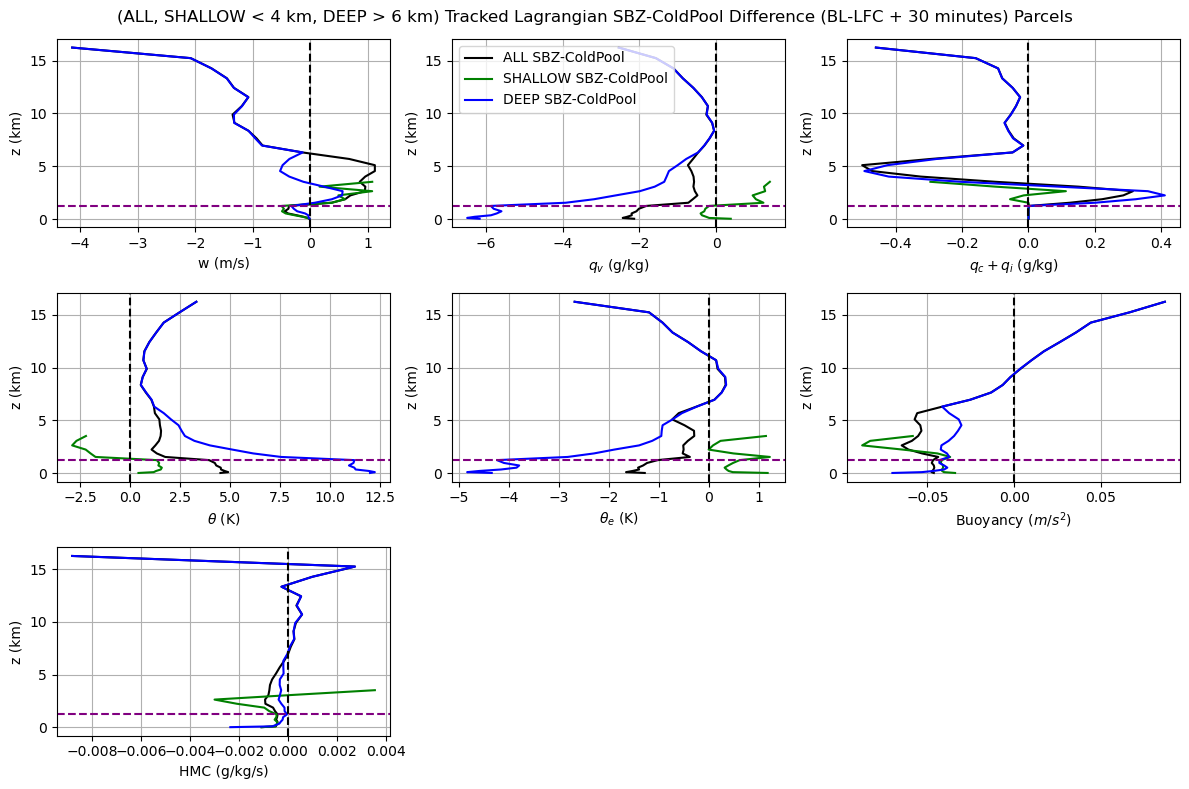

In [74]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Construct profiles dynamically using globals()
profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-ColdPool')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-ColdPool')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-ColdPool')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6, ax7 = axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6,ax7]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ-ColdPool Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()

